In [1]:
# Marketing Campaign Dataset: Customer Persona Creation Using GMM Clustering
# This notebook demonstrates how to create customer personas from marketing data using GMM clustering techniques

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.ensemble import RandomForestClassifier
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [12]:
# Load and prepare the dataset
# First, let's create the dataset from the provided data

# Create the dataset (using a sample of the provided data for demonstration)
data = """ID	Year_Birth	Education	Marital_Status	Income	Kidhome	Teenhome	Dt_Customer	Recency	MntWines	MntFruits	MntMeatProducts	MntFishProducts	MntSweetProducts	MntGoldProds	NumDealsPurchases	NumWebPurchases	NumCatalogPurchases	NumStorePurchases	NumWebVisitsMonth	AcceptedCmp3	AcceptedCmp4	AcceptedCmp5	AcceptedCmp1	AcceptedCmp2	Complain	Z_CostContact	Z_Revenue	Response
5524	1957	Graduation	Single	58138	0	0	04-09-2012	58	635	88	546	172	88	88	3	8	10	4	7	0	0	0	0	0	0	3	11	1
2174	1954	Graduation	Single	46344	1	1	08-03-2014	38	11	1	6	2	1	6	2	1	1	2	5	0	0	0	0	0	0	3	11	0
4141	1965	Graduation	Together	71613	0	0	21-08-2013	26	426	49	127	111	21	42	1	8	2	10	4	0	0	0	0	0	0	3	11	0
6182	1984	Graduation	Together	26646	1	0	10-02-2014	26	11	4	20	10	3	5	2	2	0	4	6	0	0	0	0	0	0	3	11	0
5324	1981	PhD	Married	58293	1	0	19-01-2014	94	173	43	118	46	27	15	5	5	3	6	5	0	0	0	0	0	0	3	11	0
7446	1967	Master	Together	62513	0	1	09-09-2013	16	520	42	98	0	42	14	2	6	4	10	6	0	0	0	0	0	0	3	11	0
965	1971	Graduation	Divorced	55635	0	1	13-11-2012	34	235	65	164	50	49	27	4	7	3	7	6	0	0	0	0	0	0	3	11	0
6177	1985	PhD	Married	33454	1	0	08-05-2013	32	76	10	56	3	1	23	2	4	0	4	8	0	0	0	0	0	0	3	11	0
4855	1974	PhD	Together	30351	1	0	06-06-2013	19	14	0	24	3	3	2	1	3	0	2	9	0	0	0	0	0	0	3	11	1
5899	1950	PhD	Together	5648	1	1	13-03-2014	68	28	0	6	1	1	13	1	1	0	0	20	1	0	0	3	11	0"""

# Convert string data to DataFrame
from io import StringIO
df = pd.read_csv(StringIO(data), sep='\t')

# For a more comprehensive analysis, let's create a larger synthetic dataset based on the patterns
# This simulates a real-world scenario with more data points and diverse age groups

np.random.seed(42)
n_customers = 2000

# Generate synthetic data with natural clustering tendencies and diverse age groups
synthetic_data = {
    'ID': range(1, n_customers + 1)
}

# Create distinct age cohorts for better demographic diversity
age_cohorts = np.random.choice(['Gen_Z', 'Millennial', 'Gen_X', 'Boomer'],
                              size=n_customers,
                              p=[0.15, 0.35, 0.30, 0.20])  # Realistic distribution

# Generate birth years based on cohorts
birth_years = []
for cohort in age_cohorts:
    if cohort == 'Gen_Z':
        # Ages 18-27 (born 1998-2007)
        birth_year = np.random.randint(1998, 2008)
    elif cohort == 'Millennial':
        # Ages 28-43 (born 1982-1997)
        birth_year = np.random.randint(1982, 1998)
    elif cohort == 'Gen_X':
        # Ages 44-59 (born 1966-1981)
        birth_year = np.random.randint(1966, 1982)
    else:  # Boomer
        # Ages 60-78 (born 1947-1965)
        birth_year = np.random.randint(1947, 1966)
    birth_years.append(birth_year)

synthetic_data['Year_Birth'] = birth_years

# Calculate current age for behavior modeling
current_ages = 2025 - np.array(birth_years)

# Create age-based factors for modeling behavior
age_groups = []
income_multipliers = []
digital_affinities = []
education_likelihoods = []

for age in current_ages:
    if age <= 27:  # Gen Z
        age_groups.append('Young')
        income_multipliers.append(np.random.normal(0.6, 0.15))  # Lower income
        digital_affinities.append(np.random.beta(5, 2))  # High digital
        education_likelihoods.append(np.random.normal(0.7, 0.2))  # Variable education
    elif age <= 43:  # Millennial
        age_groups.append('Adult')
        income_multipliers.append(np.random.normal(1.0, 0.2))  # Peak earning start
        digital_affinities.append(np.random.beta(4, 2))  # High digital
        education_likelihoods.append(np.random.normal(0.8, 0.15))  # Higher education
    elif age <= 59:  # Gen X
        age_groups.append('Mature')
        income_multipliers.append(np.random.normal(1.3, 0.25))  # Peak earning
        digital_affinities.append(np.random.beta(2, 3))  # Mixed digital
        education_likelihoods.append(np.random.normal(0.6, 0.2))  # Variable education
    else:  # Boomer
        age_groups.append('Senior')
        income_multipliers.append(np.random.normal(0.9, 0.3))  # Fixed/retirement income
        digital_affinities.append(np.random.beta(1, 4))  # Low digital
        education_likelihoods.append(np.random.normal(0.5, 0.2))  # Lower formal education

# Clip values to reasonable ranges
income_multipliers = np.clip(income_multipliers, 0.3, 2.0)
digital_affinities = np.clip(digital_affinities, 0.05, 0.95)
education_likelihoods = np.clip(education_likelihoods, 0.1, 1.0)

# Income generation based on age and other factors
base_incomes = []
for i, age in enumerate(current_ages):
    if age <= 27:  # Gen Z
        base_income = np.random.normal(35000, 12000)
    elif age <= 43:  # Millennial
        base_income = np.random.normal(65000, 20000)
    elif age <= 59:  # Gen X
        base_income = np.random.normal(85000, 25000)
    else:  # Boomer
        base_income = np.random.normal(70000, 30000)

    # Apply individual multiplier
    final_income = base_income * income_multipliers[i]
    base_incomes.append(final_income)

synthetic_data['Income'] = np.clip(base_incomes, 20000, 200000).astype(int)

# Education levels based on age and likelihood
education_levels = []
for likelihood in education_likelihoods:
    score = np.random.random()
    if score < 0.15:
        education_levels.append('Basic')
    elif score < 0.35:
        education_levels.append('2n Cycle')
    elif score < 0.65:
        education_levels.append('Graduation')
    elif score < 0.85:
        education_levels.append('Master')
    else:
        education_levels.append('PhD')

synthetic_data['Education'] = education_levels

# Marital status based on age
marital_statuses = []
for age in current_ages:
    if age <= 27:  # Gen Z - mostly single or together
        marital_statuses.append(np.random.choice(['Single', 'Together'], p=[0.7, 0.3]))
    elif age <= 43:  # Millennial - mixed, some married
        marital_statuses.append(np.random.choice(['Single', 'Together', 'Married', 'Divorced'],
                                                p=[0.3, 0.25, 0.4, 0.05]))
    elif age <= 59:  # Gen X - mostly married or divorced
        marital_statuses.append(np.random.choice(['Single', 'Together', 'Married', 'Divorced'],
                                                p=[0.15, 0.15, 0.6, 0.1]))
    else:  # Boomer - married, divorced, or widow
        marital_statuses.append(np.random.choice(['Married', 'Divorced', 'Widow'],
                                                p=[0.5, 0.25, 0.25]))

synthetic_data['Marital_Status'] = marital_statuses

# Children based on age and marital status
kids_home = []
teens_home = []
for i, age in enumerate(current_ages):
    marital = marital_statuses[i]

    if age <= 27:  # Gen Z - few children
        if marital in ['Together', 'Married']:
            kids_home.append(np.random.poisson(0.3))
            teens_home.append(0)
        else:
            kids_home.append(0)
            teens_home.append(0)
    elif age <= 43:  # Millennial - young children
        if marital in ['Together', 'Married']:
            kids_home.append(np.random.poisson(0.8))
            teens_home.append(np.random.poisson(0.2))
        else:
            kids_home.append(np.random.poisson(0.3))
            teens_home.append(0)
    elif age <= 59:  # Gen X - teenagers or young adults
        if marital in ['Together', 'Married']:
            kids_home.append(np.random.poisson(0.3))
            teens_home.append(np.random.poisson(0.6))
        else:
            kids_home.append(np.random.poisson(0.2))
            teens_home.append(np.random.poisson(0.3))
    else:  # Boomer - empty nesters
        kids_home.append(0)
        teens_home.append(0)

synthetic_data['Kidhome'] = np.clip(kids_home, 0, 3)
synthetic_data['Teenhome'] = np.clip(teens_home, 0, 2)

# Purchase recency based on age (older customers might shop less frequently)
recency_values = []
for age in current_ages:
    if age <= 27:
        recency_values.append(np.random.gamma(1.5, 15))  # More frequent
    elif age <= 43:
        recency_values.append(np.random.gamma(2, 18))    # Moderate
    elif age <= 59:
        recency_values.append(np.random.gamma(2.5, 20))  # Less frequent
    else:
        recency_values.append(np.random.gamma(3, 25))    # Least frequent

synthetic_data['Recency'] = np.clip(recency_values, 0, 99).astype(int)

# Spending patterns based on age and income
spending_patterns = []
wine_preferences = []
meat_preferences = []
luxury_preferences = []

for i, age in enumerate(current_ages):
    income = synthetic_data['Income'][i]
    base_spending = income * 0.15 * np.random.lognormal(0, 0.6)

    if age <= 27:  # Gen Z - experimental, less wine, more sweets
        wine_pref = np.random.beta(1, 4)
        meat_pref = np.random.beta(2, 3)
        luxury_pref = np.random.beta(1, 5)
    elif age <= 43:  # Millennial - diverse tastes
        wine_pref = np.random.beta(3, 3)
        meat_pref = np.random.beta(3, 2)
        luxury_pref = np.random.beta(2, 3)
    elif age <= 59:  # Gen X - established preferences, higher luxury
        wine_pref = np.random.beta(4, 2)
        meat_pref = np.random.beta(4, 2)
        luxury_pref = np.random.beta(3, 2)
    else:  # Boomer - traditional, quality focused
        wine_pref = np.random.beta(3, 2)
        meat_pref = np.random.beta(3, 2)
        luxury_pref = np.random.beta(2, 2)

    spending_patterns.append(base_spending)
    wine_preferences.append(wine_pref)
    meat_preferences.append(meat_pref)
    luxury_preferences.append(luxury_pref)

# Generate spending amounts
spending_base = np.array(spending_patterns)
synthetic_data['MntWines'] = (spending_base * wine_preferences * np.random.lognormal(0, 0.8)).astype(int)
synthetic_data['MntMeatProducts'] = (spending_base * meat_preferences * np.random.lognormal(0, 0.6)).astype(int)
synthetic_data['MntFruits'] = (spending_base * 0.2 * np.random.lognormal(0, 1.0)).astype(int)
synthetic_data['MntFishProducts'] = (spending_base * 0.15 * np.random.lognormal(0, 1.0)).astype(int)
synthetic_data['MntSweetProducts'] = (spending_base * 0.1 * np.random.lognormal(0, 1.1)).astype(int)
synthetic_data['MntGoldProds'] = (spending_base * luxury_preferences * np.random.lognormal(0, 1.5)).astype(int)

# Purchase channels based on digital affinity (age-based)
synthetic_data['NumWebPurchases'] = (digital_affinities * 12 * np.random.lognormal(0, 0.5)).astype(int)
synthetic_data['NumStorePurchases'] = ((1 - digital_affinities * 0.8) * 15 * np.random.lognormal(0, 0.4)).astype(int)

# Catalog purchases higher for older generations
catalog_purchases = []
for age in current_ages:
    if age <= 27:
        catalog_purchases.append(np.random.poisson(0.5))
    elif age <= 43:
        catalog_purchases.append(np.random.poisson(1))
    elif age <= 59:
        catalog_purchases.append(np.random.poisson(3))
    else:
        catalog_purchases.append(np.random.poisson(5))

synthetic_data['NumCatalogPurchases'] = catalog_purchases

# Deal purchases based on income (lower income = more deals)
deal_factor = 1 - (np.array(synthetic_data['Income']) - 20000) / 180000
synthetic_data['NumDealsPurchases'] = (deal_factor * 8 * np.random.lognormal(0, 0.5)).astype(int)

# Web visits based on digital affinity
synthetic_data['NumWebVisitsMonth'] = (digital_affinities * 15 + np.random.exponential(2)).astype(int)

# Campaign response based on age, income, and engagement
response_probs = []
for i, age in enumerate(current_ages):
    income_factor = (synthetic_data['Income'][i] - 20000) / 180000
    digital_factor = digital_affinities[i]

    if age <= 27:  # Gen Z - lower response to traditional campaigns
        base_prob = 0.05
    elif age <= 43:  # Millennial - moderate response
        base_prob = 0.12
    elif age <= 59:  # Gen X - higher response
        base_prob = 0.18
    else:  # Boomer - highest response to campaigns
        base_prob = 0.15

    final_prob = base_prob + income_factor * 0.1 + digital_factor * 0.05
    response_probs.append(np.clip(final_prob, 0, 0.4))

synthetic_data['Response'] = np.random.binomial(1, response_probs)

df = pd.DataFrame(synthetic_data)

# Clean any extreme outliers
for col in ['MntWines', 'MntMeatProducts', 'MntFruits', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']:
    df[col] = np.clip(df[col], 0, df[col].quantile(0.99))

# Ensure reasonable ranges for purchase counts
df['NumWebPurchases'] = np.clip(df['NumWebPurchases'], 0, 25)
df['NumStorePurchases'] = np.clip(df['NumStorePurchases'], 0, 30)
df['NumCatalogPurchases'] = np.clip(df['NumCatalogPurchases'], 0, 15)
df['NumDealsPurchases'] = np.clip(df['NumDealsPurchases'], 0, 20)
df['NumWebVisitsMonth'] = np.clip(df['NumWebVisitsMonth'], 0, 25)

print(f"Dataset created with {len(df)} customers")
print(f"\nAge distribution:")
df['Age'] = 2025 - df['Year_Birth']
print(f"Gen Z (18-27): {((df['Age'] >= 18) & (df['Age'] <= 27)).sum()} customers")
print(f"Millennial (28-43): {((df['Age'] >= 28) & (df['Age'] <= 43)).sum()} customers")
print(f"Gen X (44-59): {((df['Age'] >= 44) & (df['Age'] <= 59)).sum()} customers")
print(f"Boomer (60+): {(df['Age'] >= 60).sum()} customers")
print("\nDataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset created with 2000 customers

Age distribution:
Gen Z (18-27): 323 customers
Millennial (28-43): 664 customers
Gen X (44-59): 610 customers
Boomer (60+): 403 customers

Dataset shape: (2000, 21)

First few rows:


,ID,Year_Birth,Income,Education,Marital_Status,Kidhome,Teenhome,Recency,MntWines,MntMeatProducts,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumDealsPurchases,NumWebVisitsMonth,Response,Age
0,1,1993,77374,PhD,Together,1,0,3,4647.0,3992.0,...,608,574,5822.0,2,4,0,2,9,0,32
1,2,1953,60789,Graduation,Divorced,0,0,75,1983.0,3865.0,...,296,280,7050.0,0,7,7,2,1,0,72
2,3,1968,155581,2n Cycle,Together,0,1,6,11746.0,19515.0,...,920,869,76429.0,1,6,0,0,5,0,57
3,4,1972,155941,2n Cycle,Married,1,0,24,3343.0,13103.0,...,736,696,62359.0,0,7,2,0,2,1,53
4,5,1993,102568,Graduation,Married,1,0,7,2691.0,8087.0,...,299,282,10178.0,3,3,2,1,9,0,32


In [13]:
# Step 1: Exploratory Data Analysis (EDA)
# Understanding our data before creating personas

print("=== EXPLORATORY DATA ANALYSIS ===\n")

# Basic information about the dataset
print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print("\nData types:")
print(df.dtypes)

# Calculate customer age
current_year = 2025
df['Age'] = current_year - df['Year_Birth']

# Calculate total spending
spending_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spending_columns].sum(axis=1)

# Calculate total purchases
purchase_columns = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df['Total_Purchases'] = df[purchase_columns].sum(axis=1)

# Calculate total children
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

print("\nNew calculated features:")
print("- Age (derived from Year_Birth)")
print("- Total_Spending (sum of all product spending)")
print("- Total_Purchases (sum of all purchase channels)")
print("- Total_Children (kids + teens at home)")

=== EXPLORATORY DATA ANALYSIS ===

Dataset Info:
Shape: (2000, 21)
Missing values: 0

Data types:
ID                       int64
Year_Birth               int64
Income                   int64
Education               object
Marital_Status          object
Kidhome                  int64
Teenhome                 int64
Recency                  int64
MntWines               float64
MntMeatProducts        float64
MntFruits              float64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds           float64
NumWebPurchases          int64
NumStorePurchases        int64
NumCatalogPurchases      int64
NumDealsPurchases        int64
NumWebVisitsMonth        int64
Response                 int64
Age                      int64
dtype: object

New calculated features:
- Age (derived from Year_Birth)
- Total_Spending (sum of all product spending)
- Total_Purchases (sum of all purchase channels)
- Total_Children (kids + teens at home)


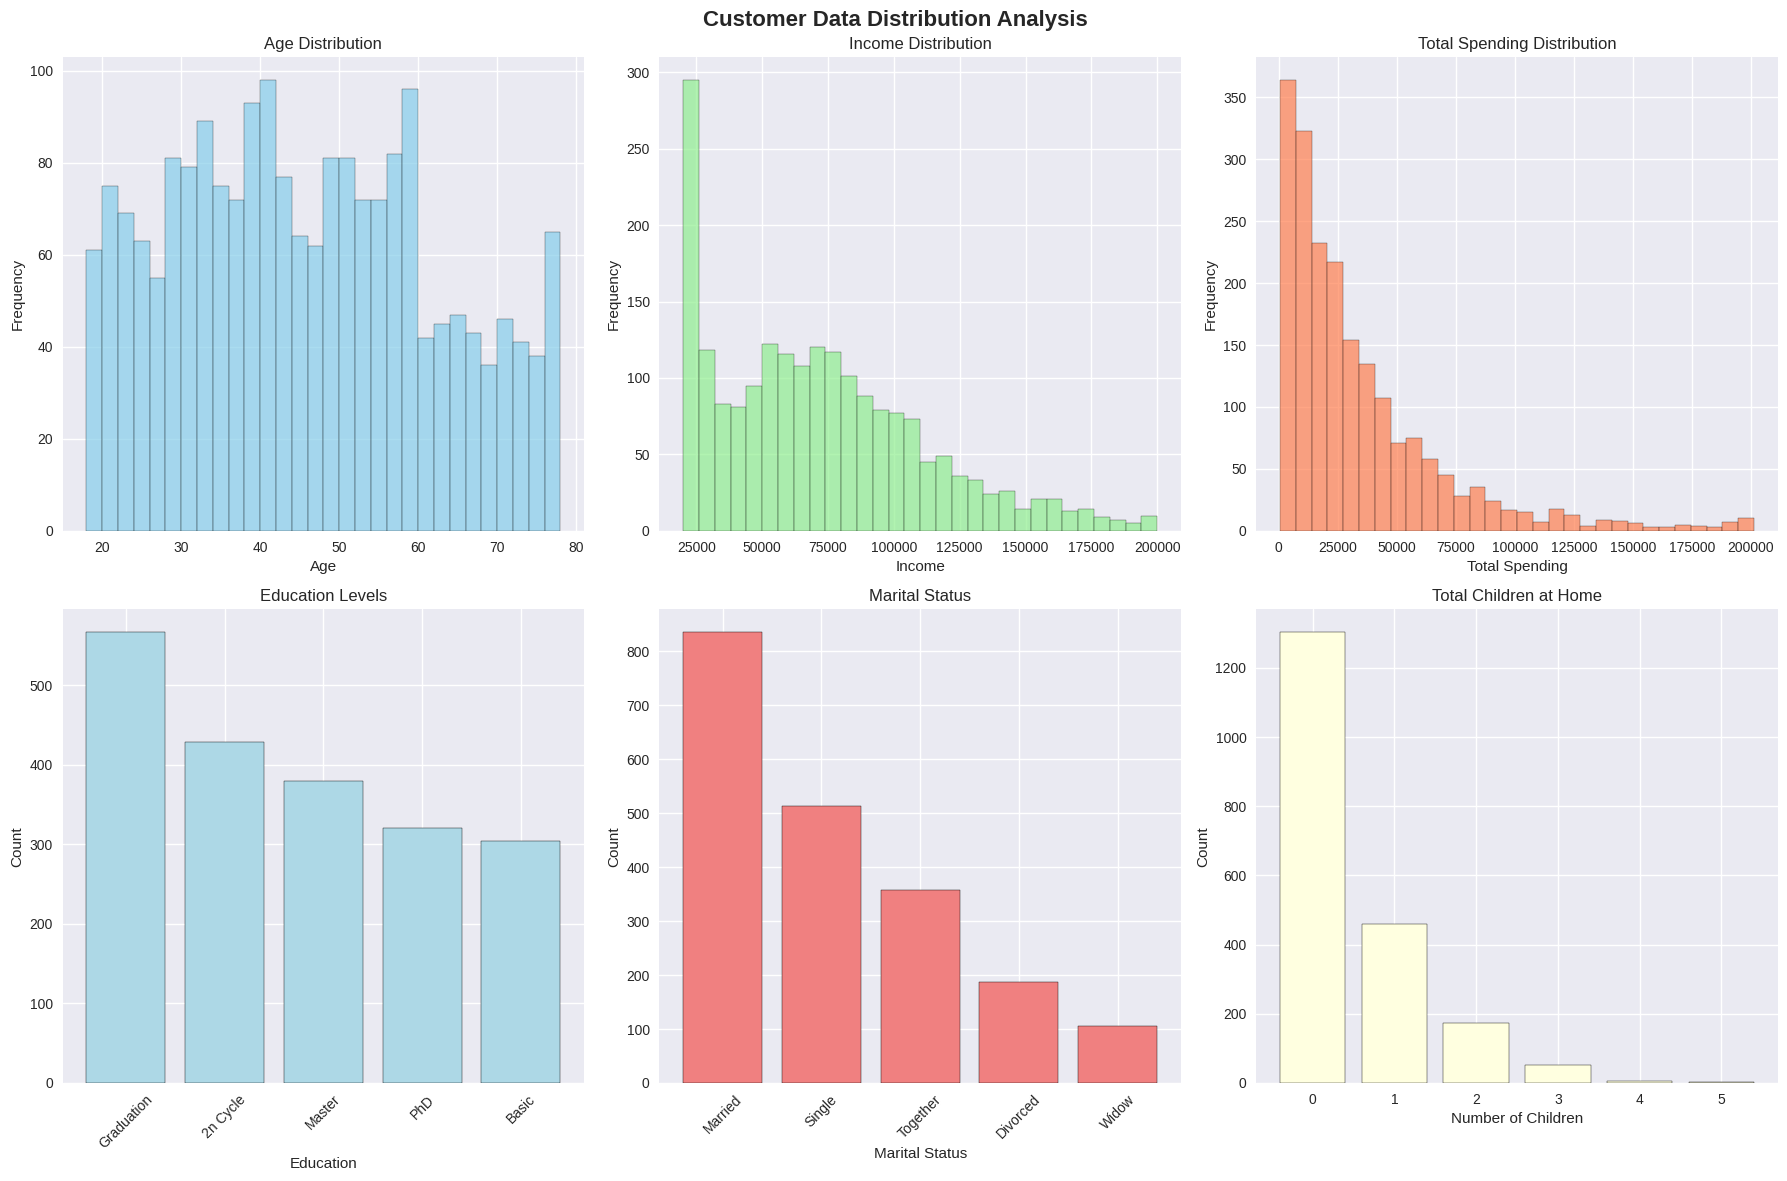


=== SUMMARY STATISTICS ===
               Age        Income  Total_Spending  Total_Purchases      Recency
count  2000.000000    2000.00000     2000.000000      2000.000000  2000.000000
mean     45.165000   71636.55150    34346.380800        10.729500    43.831000
std      16.211514   40383.83348    35557.583567         2.567611    28.904432
min      18.000000   20000.00000      575.000000         6.000000     0.000000
25%      32.000000   38357.50000     9787.500000         9.000000    20.000000
50%      44.000000   66917.00000    23076.500000        10.000000    38.000000
75%      57.000000   96521.00000    45018.250000        12.000000    63.000000
max      78.000000  200000.00000   201274.030000        24.000000    99.000000


In [14]:
# Visualize key distributions and relationships
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Customer Data Distribution Analysis', fontsize=16, fontweight='bold')

# Age distribution
axes[0, 0].hist(df['Age'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Income distribution
axes[0, 1].hist(df['Income'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Income Distribution')
axes[0, 1].set_xlabel('Income')
axes[0, 1].set_ylabel('Frequency')

# Total spending distribution
axes[0, 2].hist(df['Total_Spending'], bins=30, alpha=0.7, color='coral', edgecolor='black')
axes[0, 2].set_title('Total Spending Distribution')
axes[0, 2].set_xlabel('Total Spending')
axes[0, 2].set_ylabel('Frequency')

# Education levels
education_counts = df['Education'].value_counts()
axes[1, 0].bar(education_counts.index, education_counts.values, color='lightblue', edgecolor='black')
axes[1, 0].set_title('Education Levels')
axes[1, 0].set_xlabel('Education')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Marital status
marital_counts = df['Marital_Status'].value_counts()
axes[1, 1].bar(marital_counts.index, marital_counts.values, color='lightcoral', edgecolor='black')
axes[1, 1].set_title('Marital Status')
axes[1, 1].set_xlabel('Marital Status')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

# Total children
children_counts = df['Total_Children'].value_counts().sort_index()
axes[1, 2].bar(children_counts.index, children_counts.values, color='lightyellow', edgecolor='black')
axes[1, 2].set_title('Total Children at Home')
axes[1, 2].set_xlabel('Number of Children')
axes[1, 2].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== SUMMARY STATISTICS ===")
print(df[['Age', 'Income', 'Total_Spending', 'Total_Purchases', 'Recency']].describe())

In [15]:
# Step 2: Feature Engineering and Selection
# Create meaningful features for clustering analysis

print("=== FEATURE ENGINEERING ===\n")

# Check current data types
print("Current data types:")
print(df.dtypes)
print()

# Check for categorical variables that need conversion
categorical_cols = df.select_dtypes(include=['category', 'object']).columns
print("Categorical columns found:", categorical_cols.tolist())
print()

# Calculate age from birth year
df['Age'] = 2025 - df['Year_Birth']

# Create total spending and purchase metrics
df['Total_Spending'] = (df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
                       df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds'])

df['Total_Purchases'] = (df['NumWebPurchases'] + df['NumStorePurchases'] +
                        df['NumCatalogPurchases'] + df['NumDealsPurchases'])

# Family structure features
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Convert Education to numeric (handle categorical type properly)
education_mapping = {'Basic': 1, '2n Cycle': 2, 'Graduation': 3, 'Master': 4, 'PhD': 5}
df['Education_Level'] = df['Education'].map(education_mapping).astype(float)

# Convert Marital Status to binary feature (has partner or not)
df['Has_Partner'] = df['Marital_Status'].isin(['Together', 'Married']).astype(int)

# Create spending ratios (preferences)
df['Wine_Ratio'] = df['MntWines'] / (df['Total_Spending'] + 1)  # +1 to avoid division by zero
df['Meat_Ratio'] = df['MntMeatProducts'] / (df['Total_Spending'] + 1)
df['Luxury_Ratio'] = df['MntGoldProds'] / (df['Total_Spending'] + 1)

# Create purchase channel preferences
df['Web_Purchase_Ratio'] = df['NumWebPurchases'] / (df['Total_Purchases'] + 1)
df['Store_Purchase_Ratio'] = df['NumStorePurchases'] / (df['Total_Purchases'] + 1)
df['Catalog_Purchase_Ratio'] = df['NumCatalogPurchases'] / (df['Total_Purchases'] + 1)

# Create engagement metrics
df['Avg_Purchase_Value'] = df['Total_Spending'] / (df['Total_Purchases'] + 1)
df['Days_Since_Customer'] = (pd.to_datetime('2025-01-01') - pd.to_datetime(df['Year_Birth'].astype(str) + '-01-01')).dt.days

# Verify all features are now numeric
print("After feature engineering - data types:")
numeric_features = df.select_dtypes(include=[np.number]).columns
print(f"Numeric columns: {len(numeric_features)}")
categorical_remaining = df.select_dtypes(include=['category', 'object']).columns
print(f"Categorical columns remaining: {categorical_remaining.tolist()}")
print()

# Select features for clustering (only numeric features that make business sense)
clustering_features = [
    'Age', 'Income', 'Education_Level', 'Has_Partner', 'Total_Children',
    'Total_Spending', 'Total_Purchases', 'Avg_Purchase_Value',
    'Wine_Ratio', 'Meat_Ratio', 'Luxury_Ratio',
    'Web_Purchase_Ratio', 'Store_Purchase_Ratio', 'Catalog_Purchase_Ratio',
    'NumWebVisitsMonth', 'Recency', 'Response'
]

# Verify all selected features exist and are numeric
missing_features = [f for f in clustering_features if f not in df.columns]
if missing_features:
    print(f"WARNING: Missing features: {missing_features}")
    clustering_features = [f for f in clustering_features if f in df.columns]

non_numeric_features = []
for feature in clustering_features:
    if not pd.api.types.is_numeric_dtype(df[feature]):
        non_numeric_features.append(feature)
        print(f"WARNING: {feature} is not numeric type: {df[feature].dtype}")

if non_numeric_features:
    print(f"Removing non-numeric features: {non_numeric_features}")
    clustering_features = [f for f in clustering_features if f not in non_numeric_features]

# Create the feature matrix
X = df[clustering_features].copy()

print(f"Final feature set for clustering ({len(clustering_features)} features):")
for i, feature in enumerate(clustering_features, 1):
    print(f"  {i:2}. {feature}")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Missing values: {X.isnull().sum().sum()}")

# Handle any missing values if they exist
if X.isnull().sum().sum() > 0:
    print("Handling missing values...")
    X = X.fillna(X.median())
    print("Missing values filled with median values")

# Store the final feature list for later use
final_features = clustering_features.copy()

print("\nFeature engineering completed successfully!")
print("Sample of engineered features:")
print(X.head())

=== FEATURE ENGINEERING ===

Current data types:
ID                       int64
Year_Birth               int64
Income                   int64
Education               object
Marital_Status          object
Kidhome                  int64
Teenhome                 int64
Recency                  int64
MntWines               float64
MntMeatProducts        float64
MntFruits              float64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds           float64
NumWebPurchases          int64
NumStorePurchases        int64
NumCatalogPurchases      int64
NumDealsPurchases        int64
NumWebVisitsMonth        int64
Response                 int64
Age                      int64
Total_Spending         float64
Total_Purchases          int64
Total_Children           int64
dtype: object

Categorical columns found: ['Education', 'Marital_Status']

After feature engineering - data types:
Numeric columns: 32
Categorical columns remaining: ['Education', 'Marital_Status']

Final fe

=== DATA PREPROCESSING ===

Feature ranges before scaling:
               Age        Income  Education_Level  Has_Partner  \
count  2000.000000    2000.00000      2000.000000  2000.000000   
mean     45.165000   71636.55150         2.991500     0.597000   
std      16.211514   40383.83348         1.285789     0.490623   
min      18.000000   20000.00000         1.000000     0.000000   
25%      32.000000   38357.50000         2.000000     0.000000   
50%      44.000000   66917.00000         3.000000     1.000000   
75%      57.000000   96521.00000         4.000000     1.000000   
max      78.000000  200000.00000         5.000000     1.000000   

       Total_Children  Total_Spending  Total_Purchases  Avg_Purchase_Value  \
count     2000.000000     2000.000000      2000.000000         2000.000000   
mean         0.502500    34346.380800        10.729500         3040.222279   
std          0.803316    35557.583567         2.567611         3277.252703   
min          0.000000      575.000

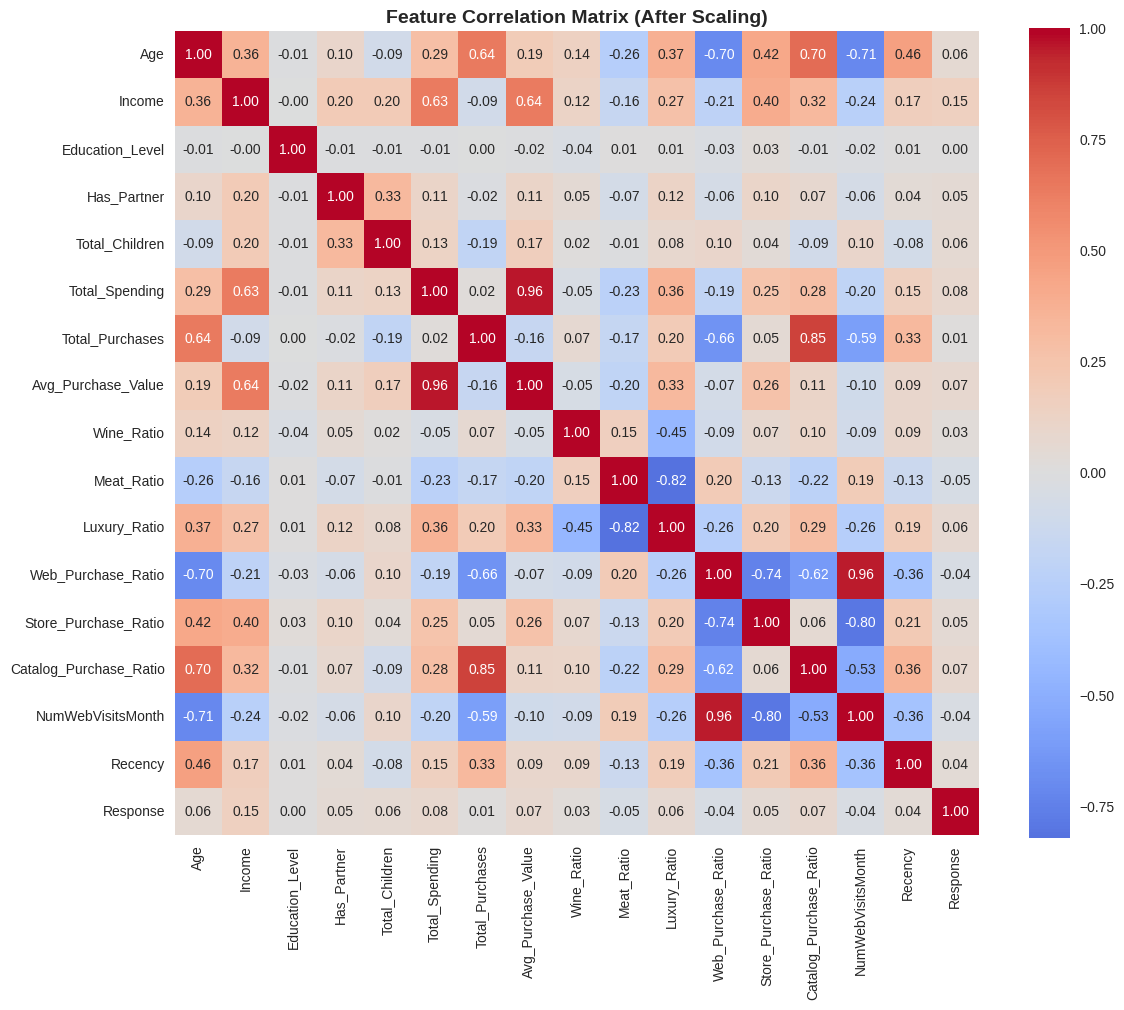


Correlation insights:
High correlation pairs (|r| > 0.5):
  Age - Total_Purchases: 0.640
  Age - Web_Purchase_Ratio: -0.702
  Age - Catalog_Purchase_Ratio: 0.700
  Age - NumWebVisitsMonth: -0.714
  Income - Total_Spending: 0.633
  Income - Avg_Purchase_Value: 0.635
  Total_Spending - Avg_Purchase_Value: 0.961
  Total_Purchases - Web_Purchase_Ratio: -0.656
  Total_Purchases - Catalog_Purchase_Ratio: 0.855
  Total_Purchases - NumWebVisitsMonth: -0.592
  Meat_Ratio - Luxury_Ratio: -0.823
  Web_Purchase_Ratio - Store_Purchase_Ratio: -0.743
  Web_Purchase_Ratio - Catalog_Purchase_Ratio: -0.617
  Web_Purchase_Ratio - NumWebVisitsMonth: 0.956
  Store_Purchase_Ratio - NumWebVisitsMonth: -0.796
  Catalog_Purchase_Ratio - NumWebVisitsMonth: -0.525


In [16]:
# Step 3: Data Preprocessing
# Scale the features for clustering

print("=== DATA PREPROCESSING ===\n")

# Check feature distributions before scaling
print("Feature ranges before scaling:")
print(X.describe())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=final_features, index=X.index)

print("\nFeatures successfully standardized")
print("Feature ranges after scaling:")
print(X_scaled_df.describe())

# Visualize the correlation matrix
plt.figure(figsize=(12, 10))
correlation_matrix = X_scaled_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Feature Correlation Matrix (After Scaling)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation insights:")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], corr_val))

if high_corr_pairs:
    print("High correlation pairs (|r| > 0.5):")
    for pair in high_corr_pairs:
        print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")
else:
    print("No highly correlated features found (|r| > 0.5)")

=== OPTIMAL NUMBER OF CLUSTERS ANALYSIS ===

Testing different numbers of clusters...
  Fitting GMM with 2 components...
  Fitting GMM with 3 components...
  Fitting GMM with 4 components...
  Fitting GMM with 5 components...
  Fitting GMM with 6 components...
  Fitting GMM with 7 components...
  Fitting GMM with 8 components...
  Fitting GMM with 9 components...
  Fitting GMM with 10 components...


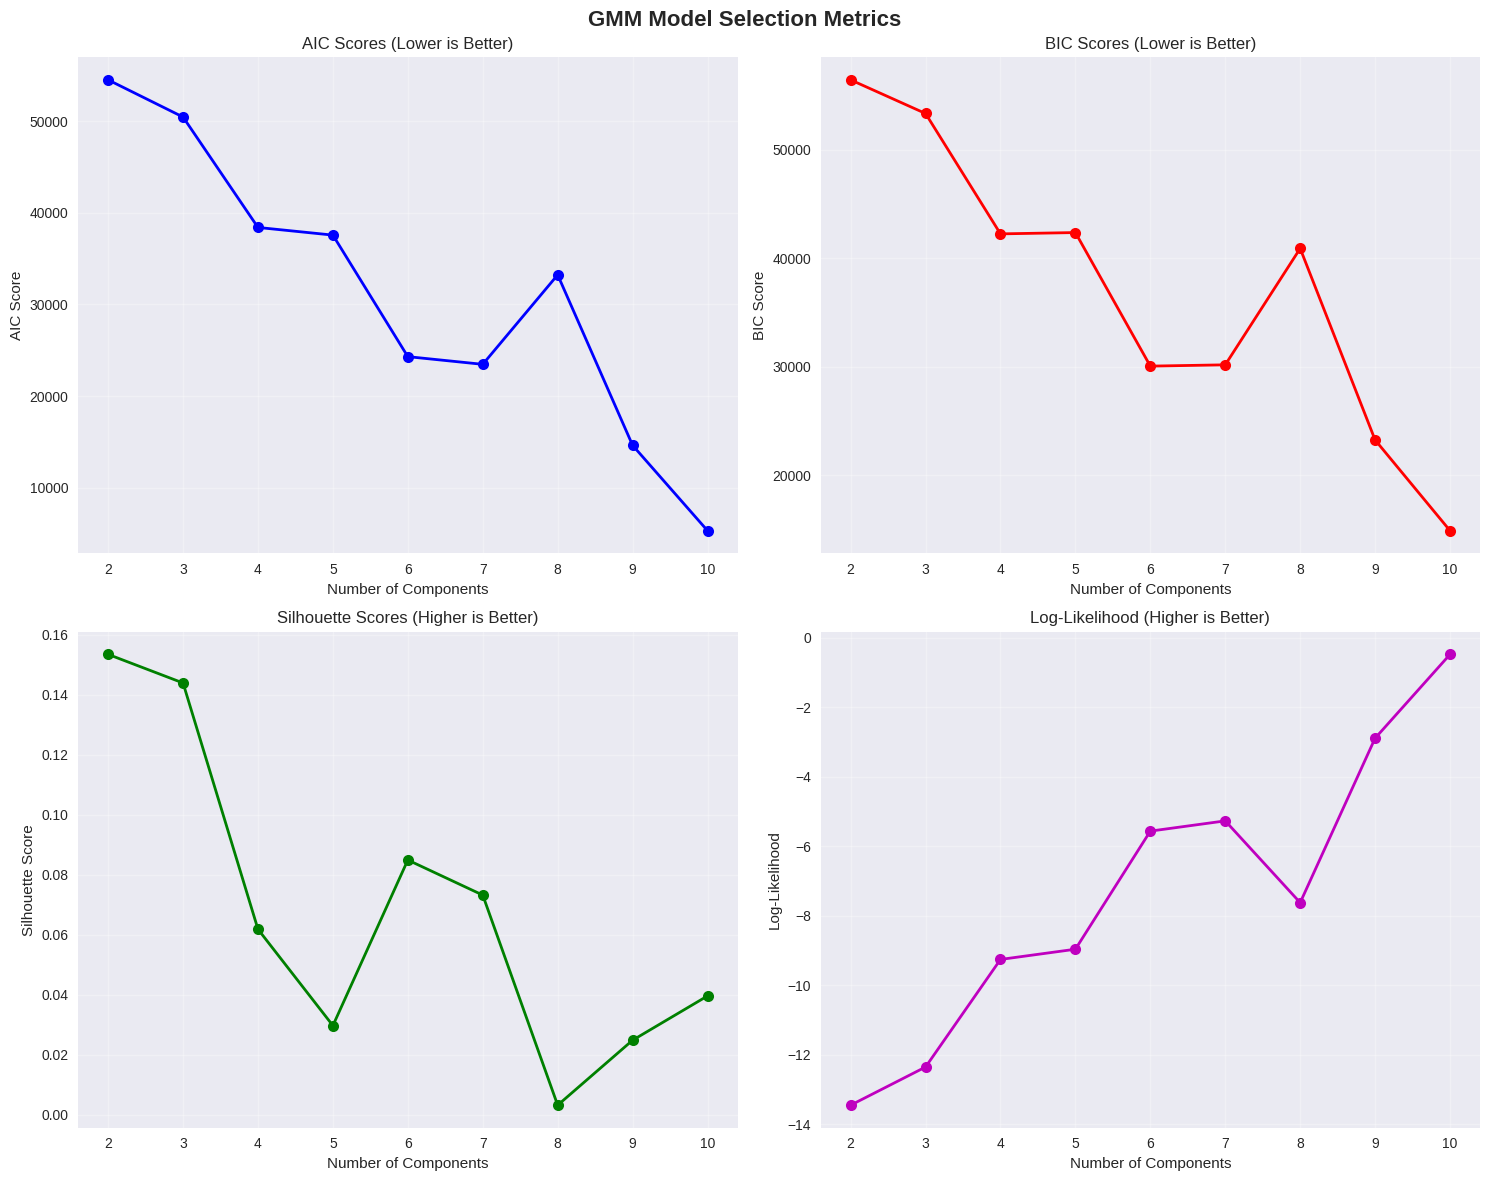


Optimal number of clusters:
  Based on AIC: 10
  Based on BIC: 10
  Based on Silhouette Score: 2

Selected optimal number of clusters: 10 (based on BIC)

Detailed scores for different numbers of clusters:
K	AIC		BIC		Silhouette	Log-Likelihood
------------------------------------------------------------
2	54508.07		56417.98		0.153		-13.46
3	50453.19		53320.85		0.144		-12.36
4	38405.44		42230.86		0.062		-9.26
5	37569.32		42352.49		0.030		-8.97
6	24307.63		30048.56		0.085		-5.56
7	23469.25		30167.93		0.073		-5.27
8	33232.14		40888.58		0.003		-7.62
9	14630.56		23244.75		0.025		-2.89
10	5317.03		14888.98		0.040		-0.47


In [17]:
# Step 4: Determine Optimal Number of Clusters using GMM
# We'll use Information Criteria (AIC, BIC) and Silhouette Score

print("=== OPTIMAL NUMBER OF CLUSTERS ANALYSIS ===\n")

# Test different numbers of clusters
k_range = range(2, 11)
aic_scores = []
bic_scores = []
silhouette_scores = []
log_likelihoods = []

print("Testing different numbers of clusters...")

for n_components in k_range:
    print(f"  Fitting GMM with {n_components} components...")

    # Fit GMM
    gmm = GaussianMixture(n_components=n_components, random_state=42,
                         covariance_type='full', max_iter=200)
    gmm.fit(X_scaled)

    # Get cluster labels
    labels = gmm.predict(X_scaled)

    # Calculate metrics
    aic = gmm.aic(X_scaled)
    bic = gmm.bic(X_scaled)
    log_likelihood = gmm.score(X_scaled)

    # Calculate silhouette score (only if we have more than 1 cluster)
    if len(np.unique(labels)) > 1:
        sil_score = silhouette_score(X_scaled, labels)
    else:
        sil_score = -1

    aic_scores.append(aic)
    bic_scores.append(bic)
    silhouette_scores.append(sil_score)
    log_likelihoods.append(log_likelihood)

# Plot the results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('GMM Model Selection Metrics', fontsize=16, fontweight='bold')

# AIC scores
axes[0, 0].plot(k_range, aic_scores, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_title('AIC Scores (Lower is Better)')
axes[0, 0].set_xlabel('Number of Components')
axes[0, 0].set_ylabel('AIC Score')
axes[0, 0].grid(True, alpha=0.3)

# BIC scores
axes[0, 1].plot(k_range, bic_scores, 'ro-', linewidth=2, markersize=8)
axes[0, 1].set_title('BIC Scores (Lower is Better)')
axes[0, 1].set_xlabel('Number of Components')
axes[0, 1].set_ylabel('BIC Score')
axes[0, 1].grid(True, alpha=0.3)

# Silhouette scores
axes[1, 0].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1, 0].set_title('Silhouette Scores (Higher is Better)')
axes[1, 0].set_xlabel('Number of Components')
axes[1, 0].set_ylabel('Silhouette Score')
axes[1, 0].grid(True, alpha=0.3)

# Log-likelihood
axes[1, 1].plot(k_range, log_likelihoods, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_title('Log-Likelihood (Higher is Better)')
axes[1, 1].set_xlabel('Number of Components')
axes[1, 1].set_ylabel('Log-Likelihood')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal number of clusters
optimal_k_aic = k_range[np.argmin(aic_scores)]
optimal_k_bic = k_range[np.argmin(bic_scores)]
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]

print(f"\nOptimal number of clusters:")
print(f"  Based on AIC: {optimal_k_aic}")
print(f"  Based on BIC: {optimal_k_bic}")
print(f"  Based on Silhouette Score: {optimal_k_silhouette}")

# Choose the optimal number based on BIC (commonly used for GMM)
optimal_k = optimal_k_bic
print(f"\nSelected optimal number of clusters: {optimal_k} (based on BIC)")

# Print detailed scores
print(f"\nDetailed scores for different numbers of clusters:")
print("K\tAIC\t\tBIC\t\tSilhouette\tLog-Likelihood")
print("-" * 60)
for i, k in enumerate(k_range):
    print(f"{k}\t{aic_scores[i]:.2f}\t\t{bic_scores[i]:.2f}\t\t{silhouette_scores[i]:.3f}\t\t{log_likelihoods[i]:.2f}")

In [18]:
# Step 5: Apply GMM Clustering with Optimal Number of Components

print("=== APPLYING GMM CLUSTERING ===\n")

# Fit the final GMM model with optimal number of components
final_gmm = GaussianMixture(n_components=optimal_k, random_state=42,
                           covariance_type='full', max_iter=200)
final_gmm.fit(X_scaled)

# Get cluster assignments and probabilities
cluster_labels = final_gmm.predict(X_scaled)
cluster_probabilities = final_gmm.predict_proba(X_scaled)

# Add results to original dataframe
df['Cluster'] = cluster_labels
df['Cluster_Probability'] = np.max(cluster_probabilities, axis=1)

print(f"GMM clustering completed with {optimal_k} components")
print(f"Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())

# Calculate final metrics
final_silhouette = silhouette_score(X_scaled, cluster_labels)
final_aic = final_gmm.aic(X_scaled)
final_bic = final_gmm.bic(X_scaled)

print(f"\nFinal model metrics:")
print(f"  Silhouette Score: {final_silhouette:.3f}")
print(f"  AIC: {final_aic:.2f}")
print(f"  BIC: {final_bic:.2f}")
print(f"  Average cluster probability: {df['Cluster_Probability'].mean():.3f}")

# Show cluster probabilities distribution
print(f"\nCluster assignment confidence:")
print(f"  High confidence (>0.8): {(df['Cluster_Probability'] > 0.8).sum()} customers ({(df['Cluster_Probability'] > 0.8).mean()*100:.1f}%)")
print(f"  Medium confidence (0.6-0.8): {((df['Cluster_Probability'] > 0.6) & (df['Cluster_Probability'] <= 0.8)).sum()} customers")
print(f"  Low confidence (<0.6): {(df['Cluster_Probability'] <= 0.6).sum()} customers")

=== APPLYING GMM CLUSTERING ===

GMM clustering completed with 10 components
Cluster distribution:
Cluster
0     26
1     15
2     87
3    323
4     15
5     70
6    307
7    208
8    666
9    283
Name: count, dtype: int64

Final model metrics:
  Silhouette Score: 0.040
  AIC: 5317.03
  BIC: 14888.98
  Average cluster probability: 0.990

Cluster assignment confidence:
  High confidence (>0.8): 1971 customers (98.6%)
  Medium confidence (0.6-0.8): 18 customers
  Low confidence (<0.6): 11 customers


In [19]:
# Step 6: Analyze and Interpret Customer Personas

print("=== CUSTOMER PERSONAS ANALYSIS ===\n")

# Calculate cluster centers in original scale
cluster_centers_scaled = final_gmm.means_
cluster_centers_original = scaler.inverse_transform(cluster_centers_scaled)
cluster_centers_df = pd.DataFrame(cluster_centers_original, columns=final_features)

print("Cluster Centers (Original Scale):")
print(cluster_centers_df.round(2))
print()

# Analyze each cluster
personas = {}
for cluster_id in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster_id]
    cluster_size = len(cluster_data)

    print(f"\n=== CLUSTER {cluster_id} (n={cluster_size}, {cluster_size/len(df)*100:.1f}%) ===")

    # Basic demographics
    avg_age = cluster_data['Age'].mean()
    avg_income = cluster_data['Income'].mean()
    avg_spending = cluster_data['Total_Spending'].mean()
    avg_purchases = cluster_data['Total_Purchases'].mean()

    # Education distribution
    education_mode = cluster_data['Education'].mode().iloc[0] if len(cluster_data['Education'].mode()) > 0 else 'Unknown'

    # Marital status
    marital_mode = cluster_data['Marital_Status'].mode().iloc[0] if len(cluster_data['Marital_Status'].mode()) > 0 else 'Unknown'

    # Children
    avg_children = cluster_data['Total_Children'].mean()

    # Purchase behavior
    avg_web_ratio = cluster_data['Web_Purchase_Ratio'].mean()
    avg_store_ratio = cluster_data['Store_Purchase_Ratio'].mean()
    avg_recency = cluster_data['Recency'].mean()

    # Spending preferences
    avg_wine_ratio = cluster_data['Wine_Ratio'].mean()
    avg_meat_ratio = cluster_data['Meat_Ratio'].mean()

    # Campaign response
    response_rate = cluster_data['Response'].mean()

    print(f"Demographics:")
    print(f"  Average Age: {avg_age:.1f} years")
    print(f"  Average Income: ${avg_income:,.0f}")
    print(f"  Most Common Education: {education_mode}")
    print(f"  Most Common Marital Status: {marital_mode}")
    print(f"  Average Children: {avg_children:.1f}")

    print(f"\nSpending Behavior:")
    print(f"  Average Total Spending: ${avg_spending:,.0f}")
    print(f"  Average Purchase Value: ${avg_spending/max(avg_purchases, 1):,.0f}")
    print(f"  Average Purchases: {avg_purchases:.1f}")
    print(f"  Days Since Last Purchase: {avg_recency:.1f}")

    print(f"\nChannel Preferences:")
    print(f"  Web Purchase Ratio: {avg_web_ratio:.1%}")
    print(f"  Store Purchase Ratio: {avg_store_ratio:.1%}")

    print(f"\nProduct Preferences:")
    print(f"  Wine Spending Ratio: {avg_wine_ratio:.1%}")
    print(f"  Meat Spending Ratio: {avg_meat_ratio:.1%}")

    print(f"\nMarketing Response:")
    print(f"  Campaign Response Rate: {response_rate:.1%}")

    # Store persona information
    personas[cluster_id] = {
        'size': cluster_size,
        'avg_age': avg_age,
        'avg_income': avg_income,
        'avg_spending': avg_spending,
        'education_mode': education_mode,
        'marital_mode': marital_mode,
        'response_rate': response_rate,
        'web_ratio': avg_web_ratio,
        'store_ratio': avg_store_ratio,
        'wine_ratio': avg_wine_ratio,
        'meat_ratio': avg_meat_ratio
    }

=== CUSTOMER PERSONAS ANALYSIS ===

Cluster Centers (Original Scale):
     Age     Income  Education_Level  Has_Partner  Total_Children  \
0  49.23  139644.21             3.17         0.70            0.96   
1  30.27   38932.86             3.47         0.47            0.47   
2  51.55  121456.82             3.02         0.45            0.54   
3  67.52   59586.51             3.02         0.51           -0.00   
4  31.53   52490.42             3.80         0.40            0.47   
5  67.42   66380.74             3.01         0.50           -0.00   
6  37.12   63849.28             3.00         0.00            0.28   
7  22.23   23954.84             3.11         0.27            0.00   
8  42.68   80384.26             2.91         1.00            0.92   
9  44.67   90398.34             2.97         0.70            0.77   

   Total_Spending  Total_Purchases  Avg_Purchase_Value  Wine_Ratio  \
0       154053.27             9.29            15746.65        0.09   
1         7080.37            1

=== CUSTOMER PERSONAS VISUALIZATION ===



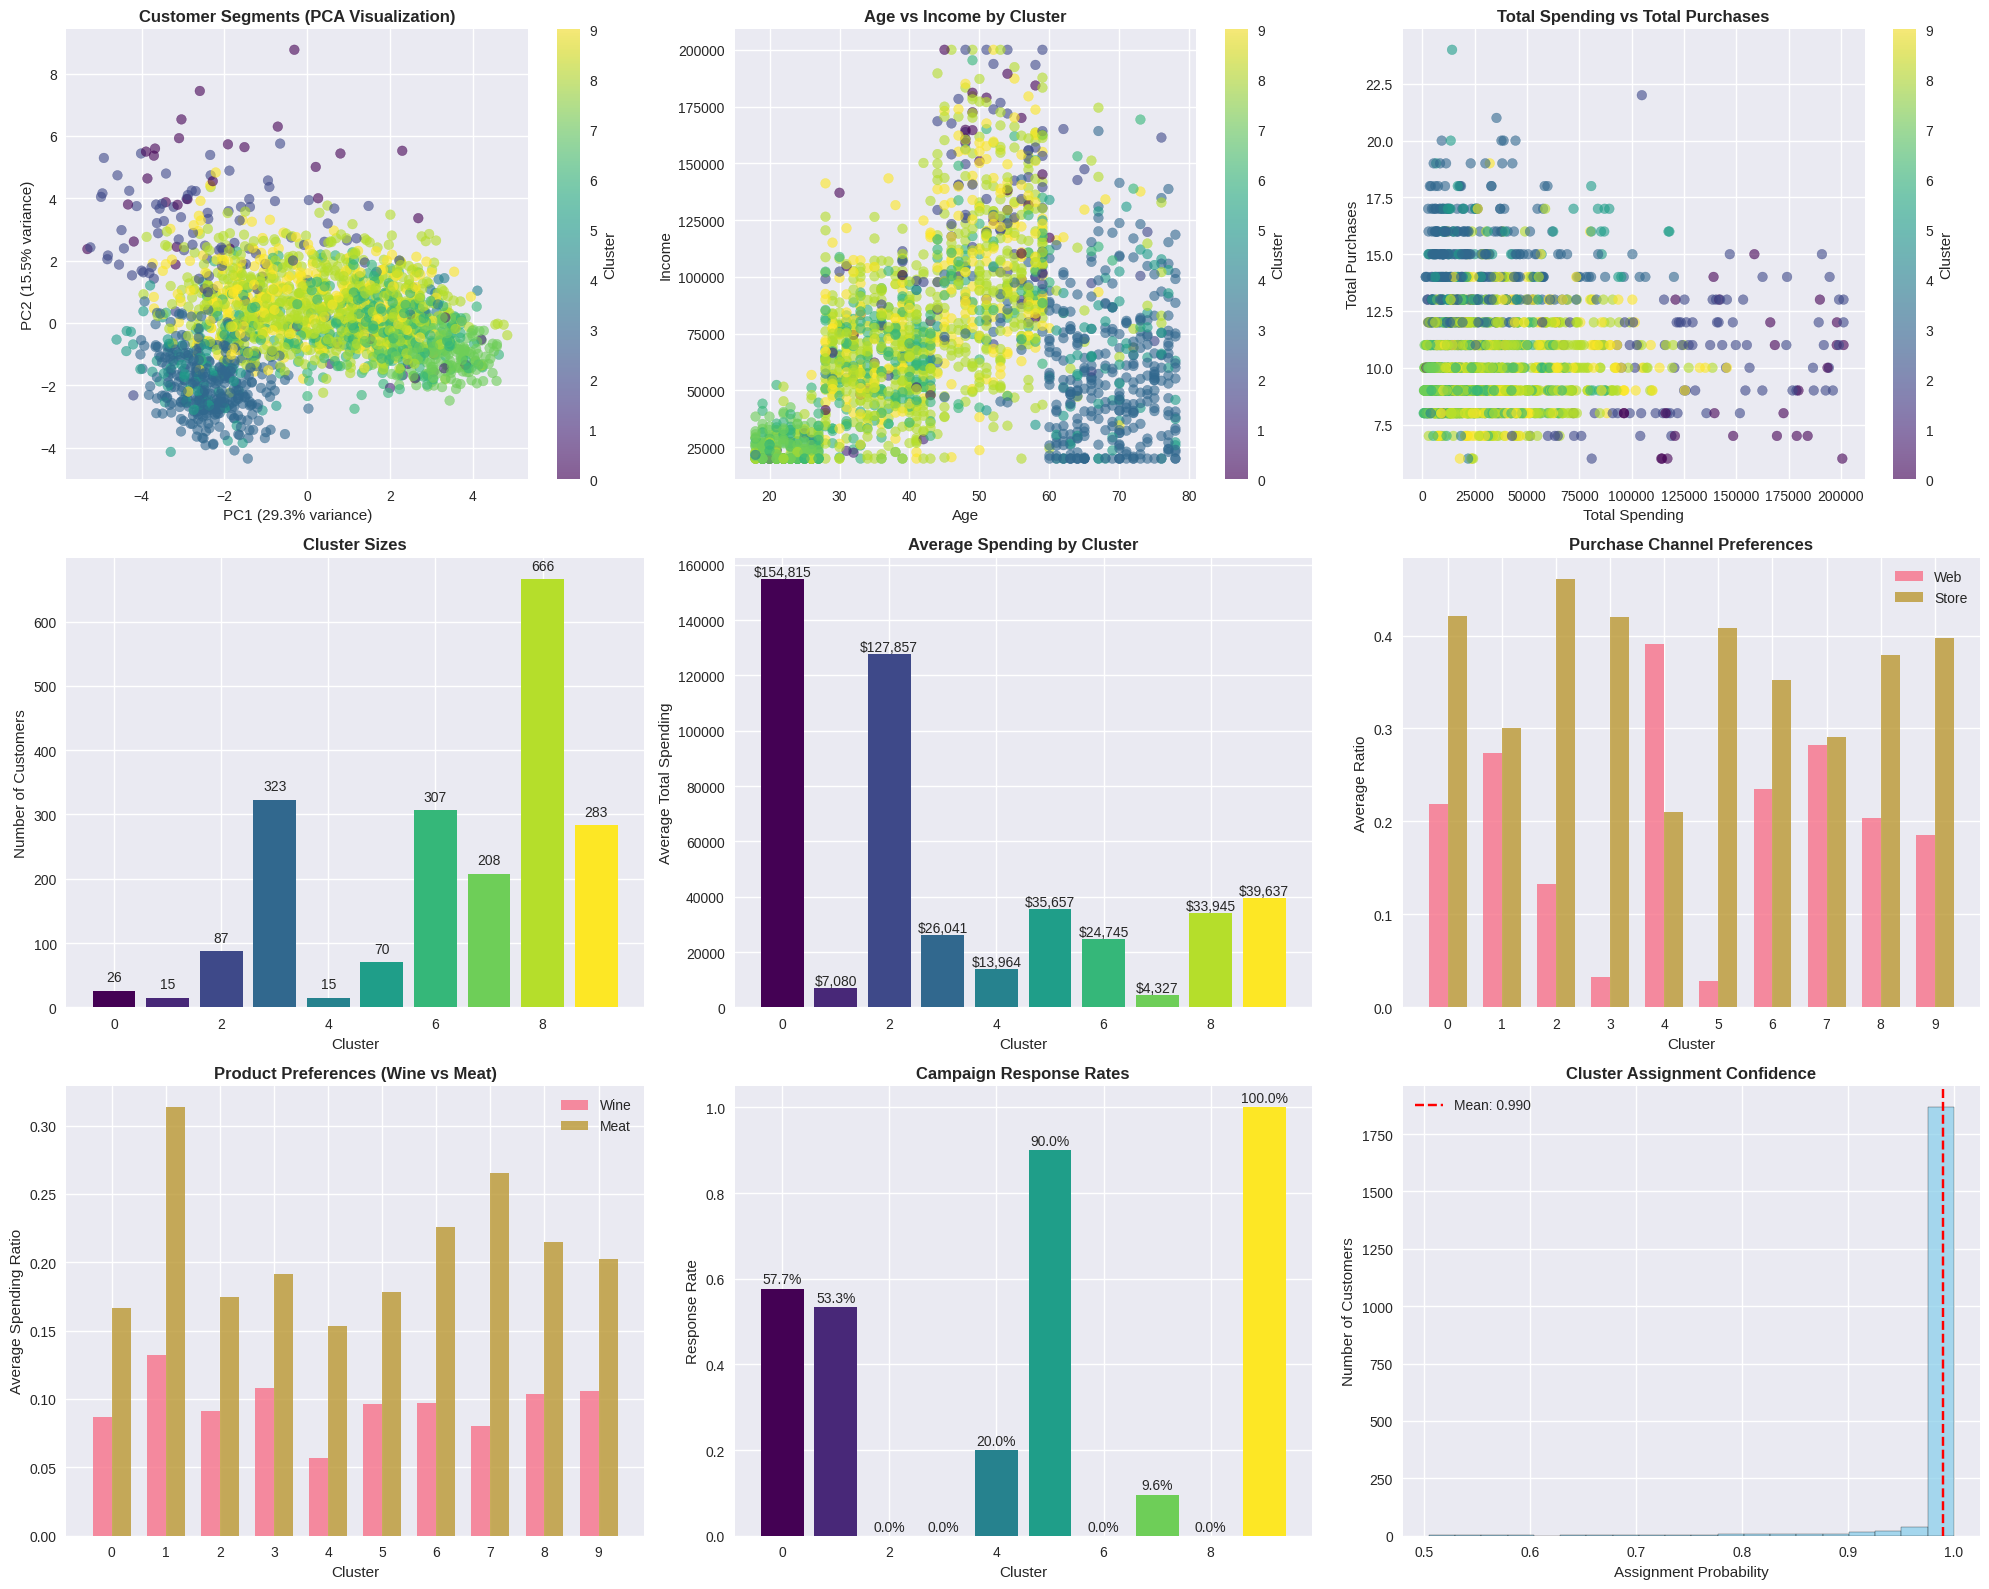

In [20]:
# Step 7: Visualize Customer Personas

print("=== CUSTOMER PERSONAS VISUALIZATION ===\n")

# Create comprehensive visualizations
fig = plt.figure(figsize=(20, 16))

# 1. PCA visualization
ax1 = plt.subplot(3, 3, 1)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.6)
plt.title('Customer Segments (PCA Visualization)', fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.colorbar(scatter, label='Cluster')

# 2. Age vs Income
ax2 = plt.subplot(3, 3, 2)
scatter = plt.scatter(df['Age'], df['Income'], c=df['Cluster'], cmap='viridis', alpha=0.6)
plt.title('Age vs Income by Cluster', fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Income')
plt.colorbar(scatter, label='Cluster')

# 3. Total Spending vs Total Purchases
ax3 = plt.subplot(3, 3, 3)
scatter = plt.scatter(df['Total_Spending'], df['Total_Purchases'], c=df['Cluster'], cmap='viridis', alpha=0.6)
plt.title('Total Spending vs Total Purchases', fontweight='bold')
plt.xlabel('Total Spending')
plt.ylabel('Total Purchases')
plt.colorbar(scatter, label='Cluster')

# 4. Cluster sizes
ax4 = plt.subplot(3, 3, 4)
cluster_counts = df['Cluster'].value_counts().sort_index()
bars = plt.bar(cluster_counts.index, cluster_counts.values, color=plt.cm.viridis(np.linspace(0, 1, len(cluster_counts))))
plt.title('Cluster Sizes', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
for bar, count in zip(bars, cluster_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha='center', va='bottom')

# 5. Average spending by cluster
ax5 = plt.subplot(3, 3, 5)
cluster_spending = df.groupby('Cluster')['Total_Spending'].mean()
bars = plt.bar(cluster_spending.index, cluster_spending.values, color=plt.cm.viridis(np.linspace(0, 1, len(cluster_spending))))
plt.title('Average Spending by Cluster', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Average Total Spending')
for bar, spending in zip(bars, cluster_spending.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'${spending:,.0f}', ha='center', va='bottom')

# 6. Purchase channel preferences
ax6 = plt.subplot(3, 3, 6)
web_ratios = df.groupby('Cluster')['Web_Purchase_Ratio'].mean()
store_ratios = df.groupby('Cluster')['Store_Purchase_Ratio'].mean()
x = np.arange(len(web_ratios))
width = 0.35
plt.bar(x - width/2, web_ratios, width, label='Web', alpha=0.8)
plt.bar(x + width/2, store_ratios, width, label='Store', alpha=0.8)
plt.title('Purchase Channel Preferences', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Average Ratio')
plt.legend()
plt.xticks(x, web_ratios.index)

# 7. Product preferences (Wine vs Meat)
ax7 = plt.subplot(3, 3, 7)
wine_ratios = df.groupby('Cluster')['Wine_Ratio'].mean()
meat_ratios = df.groupby('Cluster')['Meat_Ratio'].mean()
x = np.arange(len(wine_ratios))
plt.bar(x - width/2, wine_ratios, width, label='Wine', alpha=0.8)
plt.bar(x + width/2, meat_ratios, width, label='Meat', alpha=0.8)
plt.title('Product Preferences (Wine vs Meat)', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Average Spending Ratio')
plt.legend()
plt.xticks(x, wine_ratios.index)

# 8. Response rates by cluster
ax8 = plt.subplot(3, 3, 8)
response_rates = df.groupby('Cluster')['Response'].mean()
bars = plt.bar(response_rates.index, response_rates.values, color=plt.cm.viridis(np.linspace(0, 1, len(response_rates))))
plt.title('Campaign Response Rates', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Response Rate')
for bar, rate in zip(bars, response_rates.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{rate:.1%}', ha='center', va='bottom')

# 9. Cluster probability distribution
ax9 = plt.subplot(3, 3, 9)
plt.hist(df['Cluster_Probability'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Cluster Assignment Confidence', fontweight='bold')
plt.xlabel('Assignment Probability')
plt.ylabel('Number of Customers')
plt.axvline(df['Cluster_Probability'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["Cluster_Probability"].mean():.3f}')
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
# Step 8: Generate Customer Persona Names and Descriptions

print("=== CUSTOMER PERSONA PROFILES ===\n")

# Define persona names based on characteristics
persona_names = {}
persona_descriptions = {}

for cluster_id in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster_id]

    # Analyze characteristics for naming
    avg_age = cluster_data['Age'].mean()
    avg_income = cluster_data['Income'].mean()
    avg_spending = cluster_data['Total_Spending'].mean()
    web_ratio = cluster_data['Web_Purchase_Ratio'].mean()
    wine_ratio = cluster_data['Wine_Ratio'].mean()
    response_rate = cluster_data['Response'].mean()

    # Generate persona name based on characteristics
    if avg_income > df['Income'].quantile(0.75):
        income_desc = "Premium"
    elif avg_income > df['Income'].median():
        income_desc = "Mid-tier"
    else:
        income_desc = "Budget"

    if avg_age > 60:
        age_desc = "Senior"
    elif avg_age > 45:
        age_desc = "Mature"
    elif avg_age > 30:
        age_desc = "Adult"
    else:
        age_desc = "Young"

    if web_ratio > 0.3:
        channel_desc = "Digital"
    else:
        channel_desc = "Traditional"

    if avg_spending > df['Total_Spending'].quantile(0.75):
        spending_desc = "High-Spender"
    elif avg_spending > df['Total_Spending'].median():
        spending_desc = "Regular-Spender"
    else:
        spending_desc = "Low-Spender"

    # Combine characteristics for persona name
    persona_name = f"{income_desc} {age_desc} {channel_desc} Customer"
    persona_names[cluster_id] = persona_name

    # Generate detailed description
    education_mode = cluster_data['Education'].mode().iloc[0] if len(cluster_data['Education'].mode()) > 0 else 'Unknown'
    marital_mode = cluster_data['Marital_Status'].mode().iloc[0] if len(cluster_data['Marital_Status'].mode()) > 0 else 'Unknown'
    avg_children = cluster_data['Total_Children'].mean()

    description = f"""
{persona_name} (Cluster {cluster_id})
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Size: {len(cluster_data):,} customers ({len(cluster_data)/len(df)*100:.1f}% of total)

DEMOGRAPHICS:
• Average Age: {avg_age:.0f} years old
• Average Income: ${avg_income:,.0f} annually
• Education Level: Primarily {education_mode}
• Marital Status: Mostly {marital_mode}
• Children at Home: {avg_children:.1f} on average

SPENDING BEHAVIOR:
• Total Annual Spending: ${avg_spending:,.0f}
• Average Purchase Value: ${avg_spending/max(cluster_data['Total_Purchases'].mean(), 1):,.0f}
• Purchase Frequency: {cluster_data['Total_Purchases'].mean():.1f} purchases
• Last Purchase: {cluster_data['Recency'].mean():.0f} days ago

CHANNEL PREFERENCES:
• Web Purchases: {web_ratio:.0%} of total purchases
• Store Purchases: {cluster_data['Store_Purchase_Ratio'].mean():.0%} of total purchases
• Catalog Purchases: {cluster_data['Catalog_Purchase_Ratio'].mean():.0%} of total purchases

PRODUCT PREFERENCES:
• Wine: {wine_ratio:.0%} of spending
• Meat Products: {cluster_data['Meat_Ratio'].mean():.0%} of spending
• Luxury Items: {cluster_data['Luxury_Ratio'].mean():.0%} of spending

MARKETING INSIGHTS:
• Campaign Response Rate: {response_rate:.1%}
• Web Engagement: {cluster_data['NumWebVisitsMonth'].mean():.1f} visits/month
• Assignment Confidence: {cluster_data['Cluster_Probability'].mean():.1%}
"""

    persona_descriptions[cluster_id] = description
    print(description)
    print()

# Save persona summary
persona_summary = pd.DataFrame([
    {
        'Cluster': i,
        'Persona_Name': persona_names[i],
        'Size': personas[i]['size'],
        'Percentage': f"{personas[i]['size']/len(df)*100:.1f}%",
        'Avg_Age': f"{personas[i]['avg_age']:.0f}",
        'Avg_Income': f"${personas[i]['avg_income']:,.0f}",
        'Avg_Spending': f"${personas[i]['avg_spending']:,.0f}",
        'Response_Rate': f"{personas[i]['response_rate']:.1%}",
        'Web_Preference': f"{personas[i]['web_ratio']:.0%}",
        'Wine_Preference': f"{personas[i]['wine_ratio']:.0%}"
    }
    for i in range(optimal_k)
])

print("=== PERSONA SUMMARY TABLE ===")
print(persona_summary.to_string(index=False))

=== CUSTOMER PERSONA PROFILES ===


Premium Mature Traditional Customer (Cluster 0)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Size: 26 customers (1.3% of total)

DEMOGRAPHICS:
• Average Age: 49 years old
• Average Income: $139,066 annually
• Education Level: Primarily Graduation
• Marital Status: Mostly Married
• Children at Home: 1.0 on average

SPENDING BEHAVIOR:
• Total Annual Spending: $154,815
• Average Purchase Value: $16,565
• Purchase Frequency: 9.3 purchases
• Last Purchase: 51 days ago

CHANNEL PREFERENCES:
• Web Purchases: 22% of total purchases
• Store Purchases: 42% of total purchases
• Catalog Purchases: 19% of total purchases

PRODUCT PREFERENCES:
• Wine: 9% of spending
• Meat Products: 17% of spending
• Luxury Items: 64% of spending

MARKETING INSIGHTS:
• Campaign Response Rate: 57.7%
• Web Engagement: 7.7 visits/month
• Assignment Confidence: 99.7%



Budget Adult Traditional Customer (Cluster 1)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━